
#### let $\vec{h}$ be the incident ray coming from the ion, and $\hat{n}$ is the unit normal vector to the point of tangency. the reflected ray $\vec{r}$ is given by:
### $\vec{r}=\vec{h}-2\ (\vec{h} \cdot \hat{n})\hat{n} $


### normal vector of parabola: $dy/dx=x/6$. then at point $x_0$, $-dx/dy=-6/x_0$. so $\vec{n}=(-x_0, 6).$
### normal vector of OAP: expanded expression of the OAP is $\frac{-x^2+2hx-h^2}{(2)( 76.2)} +v $. its derivative is $ \frac{h-x}{76.2}$, and $-dx/dy=76.2/(x-h)$. then, $\vec{n}=(x_0-h, 76.2)$.

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve


#function of parabola with focal length of 3mm
def parabola(x):
        return x**2/12
    
#define horizontal and vertical controls for OAP in mm
h, v = -76.2, 450

#function of the OAP
def oap(x): 
    return -(x-h)**2/(2*76.2)+v 

#define focal length for parabolic mirror:
xfocus, yfocus = 0,3

#coordinate for focus for OAP
xfocus2, yfocus2 = h, v-38.1 

#define parameters for parabolic mirror: width in mm
width = 69.282  #mm


def plot(number_of_rays, x_offset, y_offset, xmin, xmax, ymin, ymax):
    #control desired number of rays 

    
    #ion position and offset from focal length of 3mm or (0,3)
    ion_x, ion_y =xfocus+ x_offset, yfocus + y_offset

    u=width-5

    #define ray space 
    x_rays = np.linspace(-u/2, u/2, number_of_rays) 
    
    # --- OAP coefficients general form: y = ax^2 + bx + c ---
    a, b, c = -.00656168, .0131234*h, -.00656168*h**2 + v 
    
    #plot the parabola
    x_parabola = np.linspace(-width/2, width/2, 100)
    y_parabola = parabola(x_parabola)
    plt.figure(figsize=(8, 6))
    plt.plot(x_parabola, y_parabola, label='Parabola ', color='blue')
    
    #plot the OAP
    x_oap = np.linspace(38.1+h,114.3+h,400) 
    y_oap = oap(x_oap)
    plt.plot(x_oap, y_oap, label="OAP", color='blue')


    #generate a bunch of rays originating from ion position 
    for xx in x_rays:
        #rays originate from (ion_x, ion_y) 
        xi = xx
        yi = parabola(xi)
        x_incident=[ion_x, xi] 
        y_incident=[ion_y, yi] 
    
        #plot incident rays
        plt.plot(x_incident, y_incident, 'r')
    
        #find the normal at points of intersection
        normal = np.array([-xi, 6]) # normal vector for the parabolic mirror 
        normal = normal / np.linalg.norm(normal) #normalize the vector 
    
        #define the vector of incident rays 
        incident = np.array([xi-ion_x, yi-ion_y])
    
        #reflect the rays using R = I - 2*(I·N)*N
        dotted = np.dot(incident, normal) #take the dot product of the normal vector and the incident ray
        reflected = incident - 2 * dotted * normal
        reflected = reflected / np.linalg.norm(reflected)
    
        # --- define parametric line: x = x0 + t*dx, y = y0 + t*dy ---
        x0, y0 = xi-reflected[0]*xi, yi-reflected[1]*yi
        dx, dy = reflected[0], reflected[1]
    
       # --- define equation to solve: y(t) - oap(x(t)) = 0 ---
        def intersection_function(t):
            x = x0 + t * dx
            y = y0 + t * dy
            return y - (a * x**2 + b * x + c)
        
        # --- use fsolve to find root (intersection t) ---
        initial_guess = 400  # A reasonable guess
        t_solution = fsolve(intersection_function, initial_guess)[0]
        
        # compute intersection point
        x_int = x0 + t_solution * dx
        y_int = y0 + t_solution * dy
    
        # line segment from start to intersection
        t_vals = np.linspace(0, t_solution-yi, 100)
        x_line = x0 + (t_vals+xi) * dx
        y_line = y0 + (t_vals+yi) * dy
    
        #plot the rays reflected off the parabola and onto the OAP
        plt.plot(x_line, y_line, color='green')
        
        # Mark the intersection point
        plt.plot(x_int, y_int, 'ro', label='intersection point')  # Red dot
                
    
        #find reflected rays off the OAP
        #find the normal at points of intersection
        normal2 = np.array([x_int-h, 76.2]) # normal vector for the OAP
        normal2 = normal2 / np.linalg.norm(normal2) #normalize the vector 

        #define the vector of rays that hit OAP surface (incident)
        surface=np.array([x_int-xi, y_int-yi])
    
        #reflect the rays using R = I - 2*(I·N)*N
        dotted2 = np.dot(surface, normal2) #take the dot product of the normal vector and the incident ray
        reflected2 = surface - 2 * dotted2 * normal2
        reflected2 = reflected2 / np.linalg.norm(reflected2)
    
        #reflected ray
        t_vals2=np.linspace(0, 500, 100)
        xf = x_int + reflected2[0] * t_vals2
        yf = y_int + reflected2[1] * t_vals2
    
        #plot rays reflected off the OAP
        #plt.plot([x_int, xf], [y_int, yf], 'c') #cyan
        plt.plot(xf, yf, 'c') #cyan




        # define the intersection point between the focal plane and the rays
        t = (xfocus2 - x_int) / reflected2[0]
        x_int2 = xfocus2
        y_int2 = y_int + reflected2[1] * t
            
        # mark intersection points
        #plt.plot(x_int2, y_int2, 'ro')  # Red dot
    

        ax = plt.gca() 
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        plt.grid(True)
        plt.axvline(x=xfocus2, color='k', linestyle='--')
        plt.axhline(y=yfocus2, color='k', linestyle='--')
        print('x_int ' ,x_int)
        print('y_int' ,y_int)
        print('x_i' ,xi)
        print('y_i' ,yi)
            
    print('linspace' ,x_rays)       

x_int  -32.141
y_int 437.26259440199993
x_i -32.141
y_i 86.08699008333332
x_int  0.0
y_int 411.8999987808
x_i 0.0
y_i 0.0
x_int  32.141
y_int 372.9803964134399
x_i 32.141
y_i 86.08699008333332
linspace [-32.141   0.     32.141]


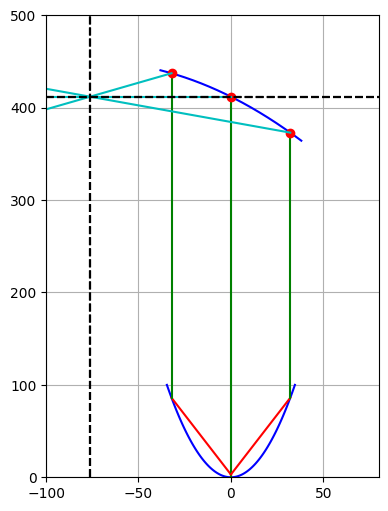

In [23]:
plot(3, 0, 0, -100, 80, 0, 500)
ax = plt.gca() # Get the current Axes object
ax.set_aspect(.5) # Set aspect ratio 

In [30]:
#plot(3, 0, 0,-90,  -60, 405, 420)

x_int  -32.141
y_int 437.26259440199993
x_i -32.141
y_i 86.08699008333332
x_int  0.0
y_int 411.8999987808
x_i 0.0
y_i 0.0
x_int  32.141
y_int 372.9803964134399
x_i 32.141
y_i 86.08699008333332
linspace [-32.141   0.     32.141]


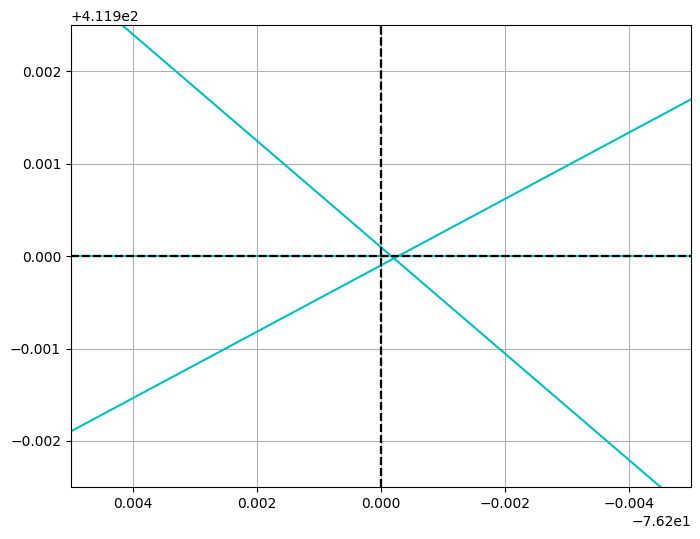

In [34]:
plot(3, 0, 0, -76.195, -76.205, 411.8975, 411.9025)

In [24]:
#returns radii list, center list for spot diagram
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import fsolve


#function of parabola with focal length of 3mm
def parabola(x):
        return x**2/12
    
#define horizontal and vertical controls for OAP in mm
h, v = -76.2, 450

#function of the OAP
def oap(x): 
    return -(x-h)**2/(2*76.2)+v 

#define focal length for parabolic mirror:
xfocus, yfocus=0,3

#parent focal length of OAP : 38.1 mm
#coordinate for focus for OAP
xfocus2, yfocus2=h, v-38.1 


#define parameters for parabolic mirror: width in mm
width = 69.282  #mm


#create empty list of y-coords to which intersection points will be appended
#ylist=[]

def radii(number_of_rays, x_offset, y_offset):
    #control desired number of rays 
    #width = 69.282  #mm

    
    #ion position and offset from focal length of 3mm or (0,3)
    ion_x, ion_y =xfocus+ x_offset, yfocus + y_offset

    #define ray space 
    x_rays = np.linspace(-width/2, width/2, number_of_rays) 
    #create empty list of y-coords to which intersection points will be appended
    # --- OAP coefficients general form: y = ax^2 + bx + c ---
    a, b, c = -.00656168, .0131234*h, -.00656168*h**2 + v 
    
    #plot the parabola
    x_parabola = np.linspace(-width/2, width/2, 100)
    y_parabola = parabola(x_parabola)
    
    #plot the OAP
    x_oap = np.linspace(38.1+h,114.3+h,400) 
    y_oap = oap(x_oap)

    ylist=[]
    #xlist=[]
    #generate a bunch of rays originating from ion position 
    for xx in x_rays:
        #rays originate from (ion_x, ion_y) 
        xi = xx
        yi = parabola(xi)
        x_incident=[ion_x, xi] 
        y_incident=[ion_y, yi] 
    
    
        #find the normal at points of intersection
        normal = np.array([-xi, 6]) # normal vector for the parabolic mirror 
        normal = normal / np.linalg.norm(normal) #normalize the vector 
    
        #define the vector of incident rays 
        incident = np.array([xi-ion_x, yi-ion_y])
    
        #reflect the rays using R = I - 2*(I·N)*N
        dotted = np.dot(incident, normal) #take the dot product of the normal vector and the incident ray
        reflected = incident - 2 * dotted * normal
        reflected = reflected / np.linalg.norm(reflected)
    
        # --- define parametric line: x = x0 + t*dx, y = y0 + t*dy ---
        x0, y0 = xi-reflected[0]*xi, yi-reflected[1]*yi
        dx, dy = reflected[0], reflected[1]
    
       # --- define equation to solve: y(t) - oap(x(t)) = 0 ---
        def intersection_function(t):
            x = x0 + t * dx
            y = y0 + t * dy
            return y - (a * x**2 + b * x + c)
       # --- use fsolve to find root (intersection t) ---
        initial_guess = 400  # A reasonable guess
        t_solution = fsolve(intersection_function, initial_guess)[0]
        
        
        # compute intersection point
        x_int = x0 + t_solution * dx
        y_int = y0 + t_solution * dy
    
        # line segment from start to intersection
        t_vals = np.linspace(0, t_solution-yi, 100)
        x_line = x0 + (t_vals+xi) * dx
        y_line = y0 + (t_vals+yi) * dy
    
    
        def x_surface(t):
            return x0 + (t+xi) * dx
    
            
        def y_surface(t):
            return y0 + (t+yi) * dy
            
        xf=x_surface(t_solution-yi)
        yf=y_surface(t_solution-yi)

        x00=x_surface(0)
        y00=y_surface(0)
                
    
        #find reflected rays off the OAP
        #find the normal at points of intersection

        #find the normal at points of intersection
        normal2 = np.array([xf-h, 76.2]) # normal vector for the OAP
        normal2 = normal2 / np.linalg.norm(normal2) #normalize the vector 

        #define the vector of rays that hit OAP surface
        surface=np.array([xf-x00, yf-y00])
    
        #reflect the rays using R = I - 2*(I·N)*N
        dotted2 = np.dot(surface, normal2) #take the dot product of the normal vector and the incident ray
        reflected2 = surface - 2 * dotted2 * normal2
        reflected2 = reflected2 / np.linalg.norm(reflected2)
    
        #reflected ray
        length = 300
        xff = xf + reflected2[0] * (length)
        yff = yf + reflected2[1] * (length)
    
    
        # define the intersection point between the focal plane and the rays
        t = (xfocus2 - xf) / reflected2[0]
        x_int = xfocus2
        y_int = yf + reflected2[1] * t

        
        ylist.append(np.array([y_int]))
        #return ylist
        #start with empty list
        xlist=[]
        
        #find the difference from the center for y coords. convert to microns
        def diff(y):
            return (y-yfocus2)*10**3 #convert to microns
        
        #append to empty list 
        for y in ylist:
            xlist.append(diff(y))

        
        #make list into numpy array
        result = np.concatenate([x.flatten() for x in xlist]), np.concatenate([y.flatten() for y in ylist])
        
    return result

In [25]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math

def spot_diagram(radius, centers, xmin, xmax, ymin, ymax):
    # create a figure and an axes object
    fig, ax = plt.subplots()
    
    
    #find radii
    radii_list=[]
    for i in range(math.floor(len(radius)//2)):
        result = (radius[len(radius)-1 - i] - radius[i])/2
        radii_list.append(result)
    
    
    #center from focus
    clist=[]
    for i in range(math.floor(len(centers)//2)):
            result2 = (yfocus2-((centers[len(radius)-1 - i] + centers[i])/2))*10**3
            clist.append(result2)  
    
    #plot the circles
    for i in range(math.floor(len(centers)//2)):
        centerss = clist[i]
        radius1 = radii_list[i]
    
        circle = patches.Circle((0,centerss), radius1, fill=False, edgecolor='blue', linewidth=2)  # Create a circle patch
        ax.add_patch(circle)  # Add the circle to the axes
    
    
    ax.set_aspect('equal', adjustable='box')
    #ax.set_xlim(-10, 10)
    #ax.set_ylim(10, 30)
    #plt.title(f'spot diagram for offset of: x={x_offset:.1f} µm, y={y_offset:.1f} µm')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    #ax.set_xlim(-20, 20) #for x10
    #ax.set_ylim(10, 40) #for x10
    ax.set_xlim(xmin, xmax)
    ax.set_ylim(ymin, ymax)
    ax.set_xlabel('µm')
    ax.set_ylabel('µm')
    plt.show()

In [26]:
#find radii, centers needed for 150 rays, x=10µm  offset, no y offset
radius_x10, centers_x10 = radii(150, 10*10**-3, 0)

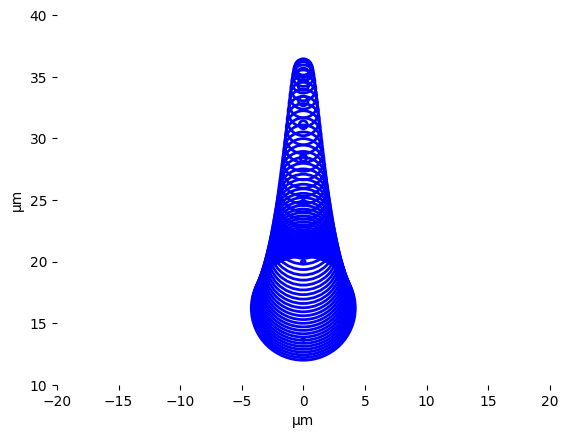

In [27]:


spot_diagram(radius_x10, centers_x10, -20, 20, 10, 40);

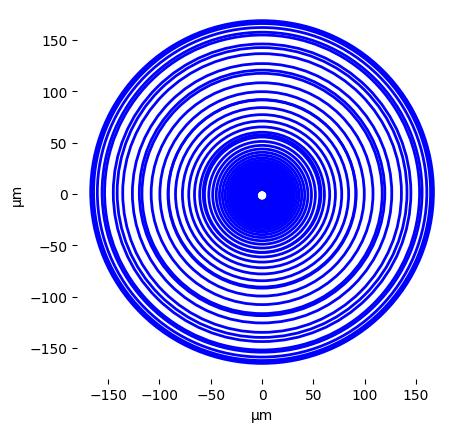

In [28]:
#find radii, centers needed for 150 rays, x=10µm  offset, no y offset
radius_y10, centers_y10 = radii(150, 0, 10*10**-3)

spot_diagram(radius_y10, centers_y10, -180, 180, -180, 180)